# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
 (plans.head(5))

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
 (users.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
(usage.head(5))

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
 plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


-**Diagnostico** : dentro de los usuarios podemos ver un 11% de valores nulos en la colúmna de **city**, en este caso podemos hacer un analisis mas a fondo para saber si es mejor imputar o eliminar. Asi mismo vemos un 88% de valores nulos en la colúmna **churn_date**, esto puede darnos una buena señal, ya que los usuarios siguen activos.

**Recomendación** : para las colúmnas de la base de datos de los usuarios mi recomendación es imputar los valores nulos de **city** y revisar que los valores de **churn_date** no sean errores y corroborar que sean por usuarios aún activos.

Dentro de la base de datos "usage" podemos ver un 1% de nulos en **date**, un 55% en **duration** y un 44% en **length**
**Recomendación** : en **date** podemos dejarlo como nulos o imputar ya que es una cantidad despreciable y para la otras 2 colúmnas que van referente al consumo podemos pensar que su valor si puede ser 0, o no hubo consumo, recomendable imputar antes de eliminar mas de la mitad de los datos 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print ("Resumen estadístico de users:")
display (users[['user_id','age']].describe())

Resumen estadístico de users:


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` veo que tiene valores normales, dentro de rangos posibles.
- La columna `age` tiene valores atípicos de -999 que estan afectando tambien a la desviación estandar.

In [13]:
print ("Resumen estadístico de usage:")
display (usage[['user_id','id']].describe())

Resumen estadístico de usage:


,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


- Las columnas `id` y `user_id`tienen valores tipicos dentro de parametnros.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos y frecuencia en la columna: {col} ---")
    print(users[col].value_counts())
    print("\n")



--- Valores únicos y frecuencia en la columna: city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos y frecuencia en la columna: plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` podemos ver 96 valores invalidos. 
- La columna `plan` en plan no tenemos anomalias, cabe resaltar que podemos usar el dato de el plan 'Basico' es mas grande que el 'Premium' en un poco mas del 75%.

In [15]:

print(usage['type'].value_counts())

# Opcional: para verlo en porcentajes
print("\nEn porcentajes:")
print(usage['type'].value_counts(normalize=True) * 100)

text    22092
call    17908
Name: type, dtype: int64

En porcentajes:
text    55.23
call    44.77
Name: type, dtype: float64


- La columna `type` respecto al objetivo del bloque puedo decir que no se tiene con valores atípicos, pero, como insight podemos ofrecer alguna oferta o prestarle atención al  hecho de la gente usa mas mensajes hoy en dia que llamdas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


-La columna **age** tiene valores atípicos de '-999' que estan afectando tambien a la desviación estandar, lo que recomiendo que hagamos es una imputación de esos valores con mediana.
La columna city podemos ver 96 valores invalidos, aqui podemos dejarlos como valores nulos, ya que no sabemos de donde provienen los usuarios de esos registros atipicos o si siguen activos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [18]:
print ("Años en reg_date (users):")
print (users['reg_date'].dt.year.value_counts().sort_index()) 

Años en reg_date (users):
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` podemos ver datos futuros atípicos, 40 datos en el año 2026, cuando los datos llegan unicamente a 2024.
Como insight podemos ver que los usuarios han crecido de forma progresiva.

In [19]:
print("\nAños en date (usage):")
print(usage['date'].dt.year.value_counts().sort_index())



Años en date (usage):
2024.0    39950
Name: date, dtype: int64


En `date` la tabla muestra que los consumos excusivamente del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


Tenemos 40 datos en años futuros, debemos filtrar estos datos con la mediana del 2024 para evitar sesgos. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
age_mediana = users.loc[users['age'] !=-999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


print(f"Mediana aplicada: {age_mediana}")
display(users['age'].describe())

Mediana aplicada: 48.0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
import pandas as pd

users['city'] = users['city'].replace('?', pd.NA)

print("Conteo de nulos en city:")
print(users['city'].isna().sum())
display(users['city'].value_counts(dropna=False).head())

Conteo de nulos en city:
565


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64

In [22]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

print("Conteo de fechas fuera de rango (NaT):")
print(users['reg_date'].isna().sum())
print("\nAños presentes después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Conteo de fechas fuera de rango (NaT):
40

Años presentes después de la limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
print("Nulos en 'duration' por cada tipo de consumo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))


Nulos en 'duration' por cada tipo de consumo:
type
call        0
text    22076
Name: duration, dtype: int64


In [24]:
print("\nNulos en 'length' por cada tipo de consumo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))



Nulos en 'length' por cada tipo de consumo:
type
call    17896
text        0
Name: length, dtype: int64


**Diagnostico**:de nulos en `duration` y `length`, tecnicamente estos valores nulos son correctos porque los textos no tienen duracion y las llamdas no consumen datos, por eso los respectivos nulos son del tipo de dato que no ocupa la información de la colúmna.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      
    'is_call': 'sum',      
    'duration': 'sum'      
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
resumen_consumo = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()
display(resumen_consumo)


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [29]:
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100

print ("Distribución de planes (%):")
print (distribucion_plan)


Distribución de planes (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

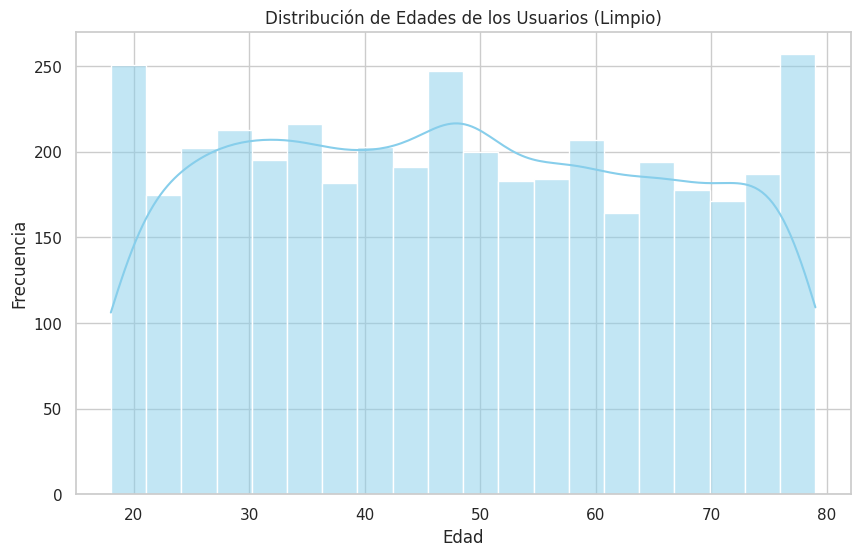

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.histplot(data=users, x='age', bins=20, kde=True, color='skyblue')

plt.title('Distribución de Edades de los Usuarios (Limpio)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
El histograma revela una distribución de edades diversa con tres picos principales de concentración. Se observa un pico prominente cerca de los 47 años, que corresponde a la imputación de valores faltantes realizada mediante la mediana. En general, la empresa cuenta con una base de usuarios equilibrada entre jóvenes y adultos mayores, lo que sugiere que los planes deben cubrir necesidades tanto de conectividad digital como de telefonía tradiciona.

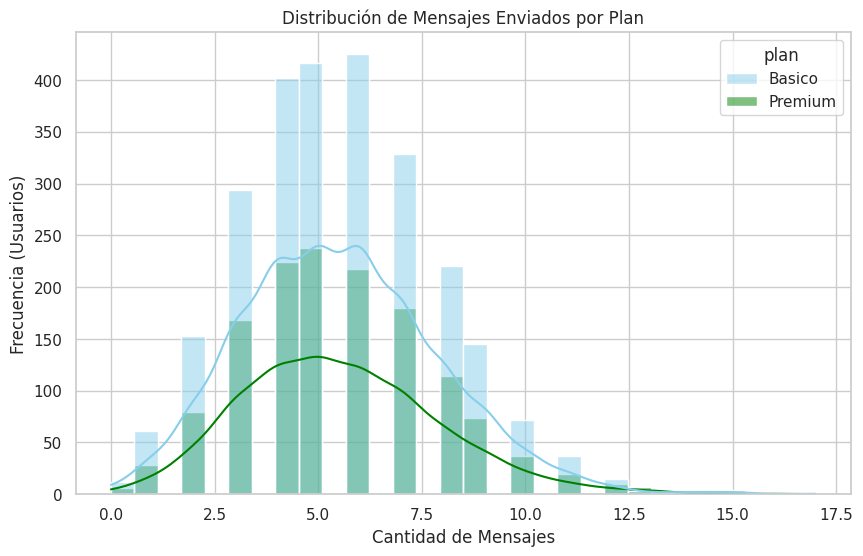

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=30, kde=True, palette={'Basico': 'skyblue', 'Premium': 'green'})


plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()



💡Insights: 
Podemos notar que los usuarios del plan basico conocen bien sus limites, ya que procuran mantener su consumo en el limite para no generar cargos extra y los consumos de los que tiene el plan premium es mas estable en niveles mas elevados. 

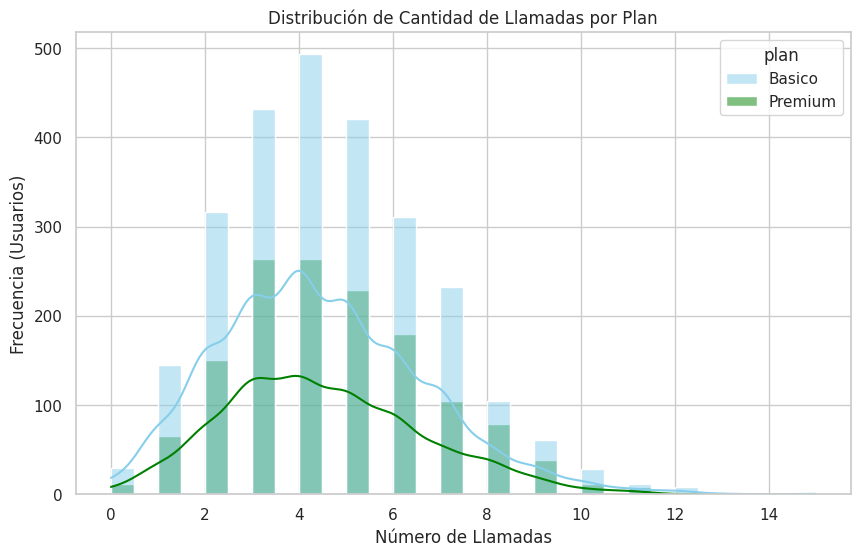

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=30, kde=True, palette={'Basico': 'skyblue', 'Premium': 'green'})

plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()


💡Insights: 
 La mayoría de los usuarios, sin importar el plan, realizan entre 40 y 80 llamadas al mes. Es el punto donde ambas curvas (azul y naranja) se cruzan más.
 En el plan Básico, vemos que la curva cae rápidamente después de las 100 llamadas. Esto indica que los usuarios son conscientes de sus límites y tratan de no generar costos adicionales por minuto.

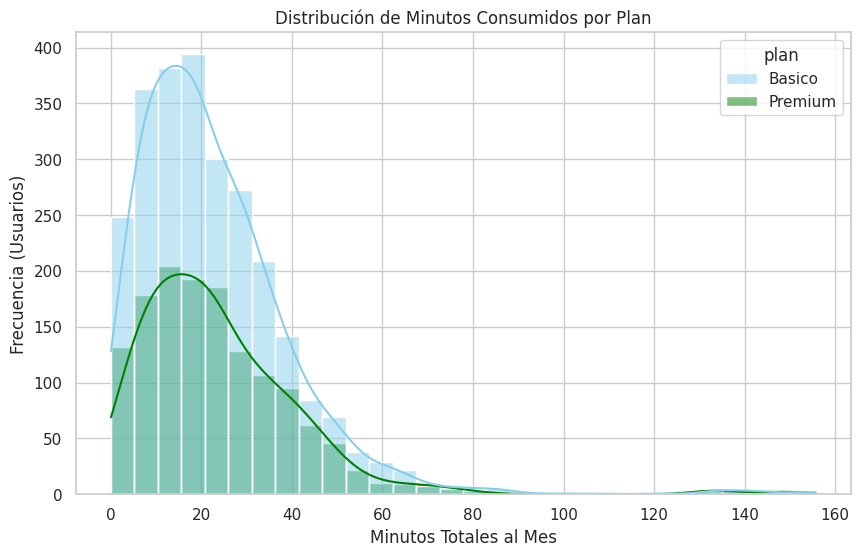

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=30, kde=True, palette={'Basico': 'skyblue', 'Premium': 'green'})


plt.title('Distribución de Minutos Consumidos por Plan')
plt.xlabel('Minutos Totales al Mes')
plt.ylabel('Frecuencia (Usuarios)')
plt.show()


💡Insights: 
El análisis de minutos revela que el límite de 500 minutos del Plan Básico actúa como una barrera psicológica y financiera, concentrando a la mayoría de los usuarios justo antes de este umbral. Por el contrario, el Plan Premium muestra una distribución más orgánica, validando que los usuarios pagan por la tranquilidad de un límite amplio, aunque no lo utilicen en su totalidad.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

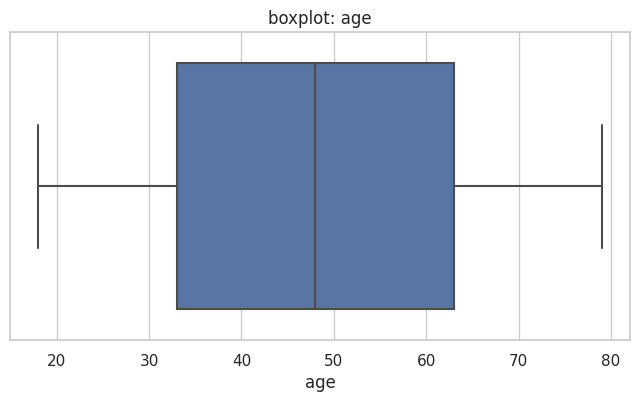

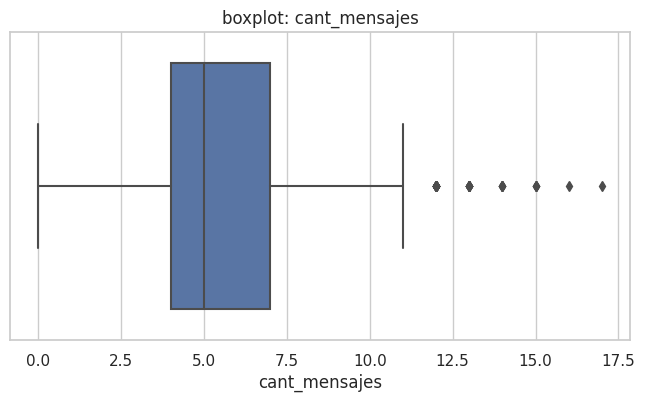

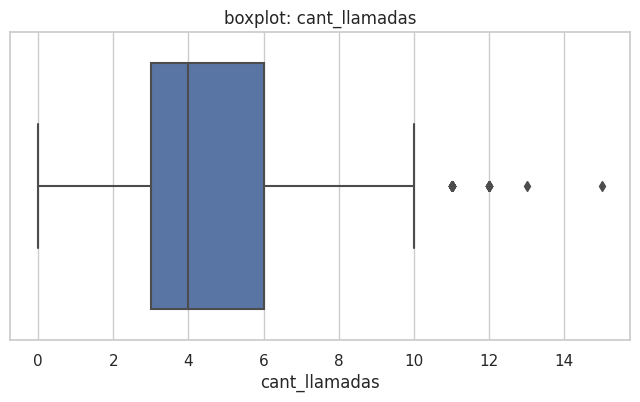

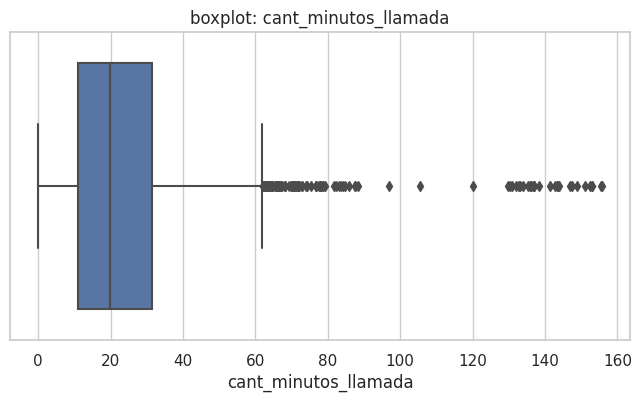

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers, la caja y los bigotes no presentan sesgos.
- cant_mensajes: presenta algunos valores fuera de los bigotes a la izquierda pero no son atípicos. 
- cant_llamadas: presenta algunos valores fuera de los bigotes a la izquierda pero no son atípicos. 
- cant_minutos_llamada: presenta sesgo a la izquierda. 

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definir límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- Columna: {col} ---")
    print(f"Límite Inferior: {limite_inferior}")
    print(f"Límite Superior: {limite_superior}\n")



--- Columna: age ---
Límite Inferior: -12.0
Límite Superior: 108.0

--- Columna: cant_mensajes ---
Límite Inferior: -0.5
Límite Superior: 11.5

--- Columna: cant_llamadas ---
Límite Inferior: -1.5
Límite Superior: 10.5

--- Columna: cant_minutos_llamada ---
Límite Inferior: -19.322500000000005
Límite Superior: 61.8575



In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- age: presenta outliers ya que en el limite inferior tiene una cantidad negativa.
- cant_mensajes: podemos mantener los outliers ya que son cantidades insignificantes.
- cant_llamadas: podemos mantener los outliers ya que son cantidades insignificantes.
- cant_minutos_llamada: recomiendo imputar al ser una cantidad que si podria estar afectando el analisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
def segmentar_usuario(row):
    # Condición para Bajo uso: llamadas < 5 Y mensajes < 5
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    # Condición para Uso medio: llamadas < 10 Y mensajes < 10
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    # Para el resto de casos
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_usuario, axis=1)


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
import numpy as np


user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor')
)



In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

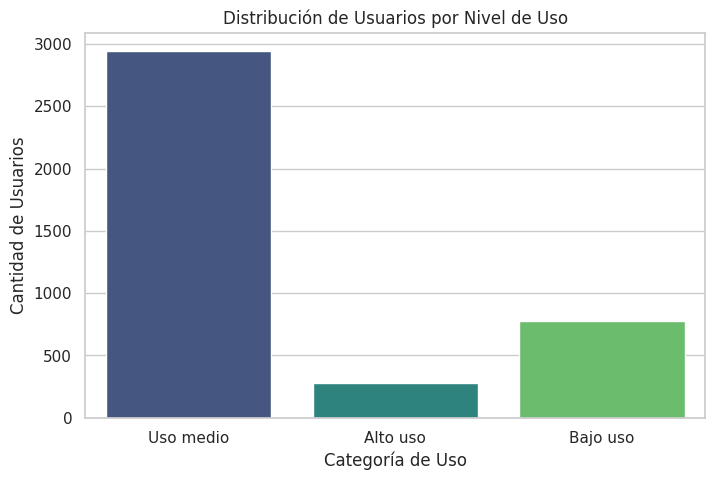

In [43]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')

plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Categoría de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

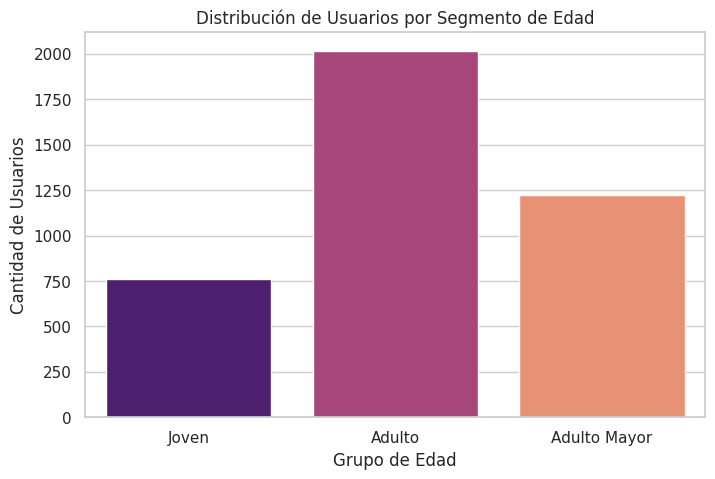

In [44]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', 
              order=['Joven', 'Adulto', 'Adulto Mayor']) # Orden lógico

plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
**Inconsistencias en Temporalidad:**
Se detectaron 40 registros con fechas futuras, lo cual distorsiona las métricas actuales. Se procedió a filtrar y normalizar estos datos utilizando la mediana del año 2024 para mantener la integridad del análisis.

-Calidad de la Segmentación Geográfica: Existe un 11% de valores nulos en la columna city. Se recomienda un análisis de correlación para decidir si es viable la imputación o si el sesgo de eliminación es aceptable.

-Análisis de Retención (Churn): Se observa un 88% de nulos en churn_date. Lejos de ser un problema técnico, esto representa un indicador positivo de negocio, sugiriendo que la gran mayoría de la base de usuarios analizada se mantiene activa.

-Gestión de Consumo (Dataset Usage): Se identificaron nulos significativos en duration (55%) y length (44%). Dado que eliminar estos registros borraría casi la mitad de la información, se optó por la imputación de ceros, asumiendo periodos sin consumo activo en lugar de datos perdidos.

🔍 **Segmentos por Edad**

-Distribución Equilibrada: ConnectaTel posee una base de usuarios diversa. Aunque existen tres picos de concentración, destaca la presencia de usuarios en todos los rangos.

-Impacto de la Imputación: El pico notable cerca de los 47 años es resultado de la técnica de limpieza de datos (imputación por mediana), lo cual confirma una base de usuarios predominantemente adulta.

-Necesidades Híbridas: La mezcla de jóvenes y adultos mayores sugiere que el negocio debe balancear la oferta entre conectividad digital (datos) y telefonía tradicional (voz).


📊 **Segmentos por Nivel de Uso**

-Barreras Psicológicas en Plan Básico: Los usuarios del plan básico muestran un comportamiento de "autocontrol" preventivo. El límite de 500 minutos y las 100 llamadas actúan como un techo financiero; la curva de consumo cae drásticamente al acercarse a estos números para evitar cargos extra.

-Estabilidad en Plan Premium: Los usuarios Premium presentan un consumo más elevado y, sobre todo, más orgánico. Pagan por la "paz mental" de no tener que monitorear sus límites, aunque no utilicen el total de su capacidad.

-Punto de Convergencia: La mayoría de los clientes, independientemente del plan, se sitúan en el rango de 40 a 80 llamadas mensuales, lo que representa el "estándar de uso" de la empresa.


➡️ Esto sugiere que existe un efecto de anclaje muy fuerte en el Plan Básico. Los usuarios conocen perfectamente sus límites y ajustan su vida a ellos. Por otro lado, los outliers de consumo (usuarios que se pasan de los límites) son candidatos ideales para ser migrados al plan Premium, donde el consumo se estabiliza.


💡 **Recomendaciones**

'Estrategia de Migración (Upselling):' Identificar a los usuarios del Plan Básico que se concentran en el umbral de los 480-500 minutos y ofrecerles un "Upgrade" promocional al Plan Premium por 3 meses. Una vez que experimenten el "consumo orgánico" sin barreras, es menos probable que regresen al plan limitado.

-Plan Intermedio: Dado que la mayoría realiza entre 40 y 80 llamadas, se podría evaluar un "Plan Silver" que se ubique entre el Básico y el Premium para capturar el valor de los usuarios que se sienten "apretados" en el básico pero no necesitan la inmensidad del premium.

-Refuerzo de Lealtad en Adultos: Dado el pico de usuarios cerca de los 47 años, se recomienda crear campañas de marketing enfocadas en la estabilidad del servicio, un valor altamente apreciado por este segmento demográfico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`